# Single value deconvolution of replication timing

May 6, 2024

Goal: Compute the replication timings for each of the three configs. Output the replication timing for each chromosome 10k windows and for each gene. 

Procedure:
1. Compute the 10k occupancy values for both replicates
2. Setup deconvolution model in which a single step transition from 1 to 2 copies is learned
3. Compute the replication timing as the position in which the step occurs
4. Interpolate the replication timing for bins in which there was not enough depth to compute the timing.
5. Identify the replication timing for each gene
6. Save the chromosome and gene level replication timing to disk for each model.

In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:23.817
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:42.979


In [6]:
# Normalize data and compute raw data replicating timings
mnase_analysis_rep1.normalize_and_compute_raw_replication_timing()
mnase_analysis_rep2.normalize_and_compute_raw_replication_timing()

In [274]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver

config_types = ['shared', 'distinct', 'delta']
solvers = []

from src.timer import Timer

timer = Timer()

for config_type in config_types:
    print(f"Creating replication timing for config: {config_type}")
    
    solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1,
                                                      mnase_analysis_rep2,
                                                     config_type=config_type)
    solver.deconvolve_all_chromosomes()
    solver.create_replication_timing_indices()
    solver.compute_gene_replication_timing()
    solver.save_replication_timings("output/replication_profiles/")
    solvers.append(solver)
    
    timer.print_time("Done.")


shared
Deconvolving with config: shared, <class 'src.single_G1_config.Config'>, <function calcH at 0x7f82e411f700>
Chromosome 1
0/111 - 00:00:00.647
40/111 - 00:00:26.170
done. - 00:00:58.568
Chromosome 2
40/402 - 00:00:22.123
80/402 - 00:00:46.492
120/402 - 00:01:10.195
160/402 - 00:01:32.282
200/402 - 00:01:57.942
240/402 - 00:02:23.134
280/402 - 00:02:48.057
320/402 - 00:03:13.417
360/402 - 00:03:38.180
400/402 - 00:04:02.787
done. - 00:05:02.824
Chromosome 3
0/154 - 00:00:00.614
80/154 - 00:00:43.612
120/154 - 00:01:08.469
done. - 00:06:31.416
Chromosome 4
40/761 - 00:00:20.307
80/761 - 00:00:45.083
120/761 - 00:01:10.560
160/761 - 00:01:35.672
200/761 - 00:02:01.499
240/761 - 00:02:28.082
280/761 - 00:02:47.100
360/761 - 00:03:33.736
400/761 - 00:03:58.838
480/761 - 00:04:44.687
520/761 - 00:05:06.046
560/761 - 00:05:28.157
640/761 - 00:06:14.704
680/761 - 00:06:39.989
720/761 - 00:07:04.783
done. - 00:14:03.362
Chromosome 5
40/284 - 00:00:24.956
80/284 - 00:00:51.013
120/284 - 00

160/402 - 00:01:33.430
200/402 - 00:02:00.179
240/402 - 00:02:25.686
280/402 - 00:02:51.459
320/402 - 00:03:17.183
360/402 - 00:03:42.344
400/402 - 00:04:07.509
done. - 00:05:08.200
Chromosome 3
0/154 - 00:00:00.632
80/154 - 00:00:44.593
120/154 - 00:01:09.664
done. - 00:06:38.735
Chromosome 4
40/761 - 00:00:20.657
80/761 - 00:00:46.253
120/761 - 00:01:11.852
160/761 - 00:01:36.986
200/761 - 00:02:03.200
240/761 - 00:02:30.260
280/761 - 00:02:49.453
360/761 - 00:03:36.910
400/761 - 00:04:01.759
480/761 - 00:04:48.626
520/761 - 00:05:09.900
560/761 - 00:05:32.000
640/761 - 00:06:19.307
680/761 - 00:06:45.554
720/761 - 00:07:10.324
done. - 00:14:16.143
Chromosome 5
40/284 - 00:00:25.055
80/284 - 00:00:51.577
120/284 - 00:01:17.145
160/284 - 00:01:42.974
200/284 - 00:02:08.576
240/284 - 00:02:30.549
280/284 - 00:02:52.427
done. - 00:17:10.229
Chromosome 6
40/131 - 00:00:21.726
80/131 - 00:00:44.352
120/131 - 00:01:10.782
done. - 00:18:27.709
Chromosome 7
40/541 - 00:00:23.932
80/541 - 00:

In [278]:
config_type = 'shared'
print(f"Creating replication timing for config: {config_type}")

solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1,
                                                  mnase_analysis_rep2,
                                                 config_type=config_type)
solver.deconvolve_chr_all_bins(10)

# solver.deconvolve_all_chromosomes()
# solver.create_replication_timing_indices()
# solver.compute_gene_replication_timing()
# solver.save_replication_timings("output/replication_profiles/")
# solvers.append(solver)

# timer.print_time("Done.")

Creating replication timing for config: shared
Deconvolving with config: shared, <class 'src.single_G1_config.Config'>, <function calcH at 0x7f82e411f700>
40/368 - 00:00:20.531
80/368 - 00:00:45.830
120/368 - 00:01:11.446
160/368 - 00:01:36.562
200/368 - 00:02:02.729
280/368 - 00:02:50.997
320/368 - 00:03:17.230
360/368 - 00:03:44.008


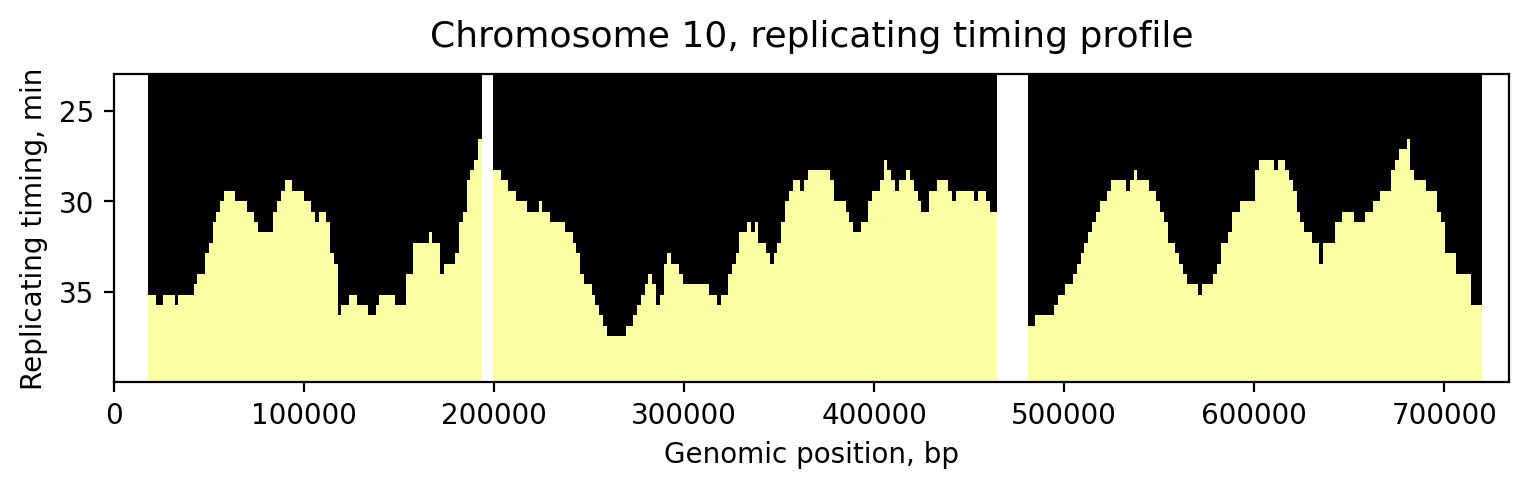

In [326]:
solver.plot_deconvolved_chrom_f()

In [283]:
solver.convert_to_replication_timing()

AttributeError: 'StepReplicationChromatinDeconvolveSolver' object has no attribute 'convert_to_replication_timing'

In [333]:
from src.stepwise_replication_solver import convert_to_replication_timing

repl_timing = convert_to_replication_timing(chr10_repl, [10], interpolate=True)

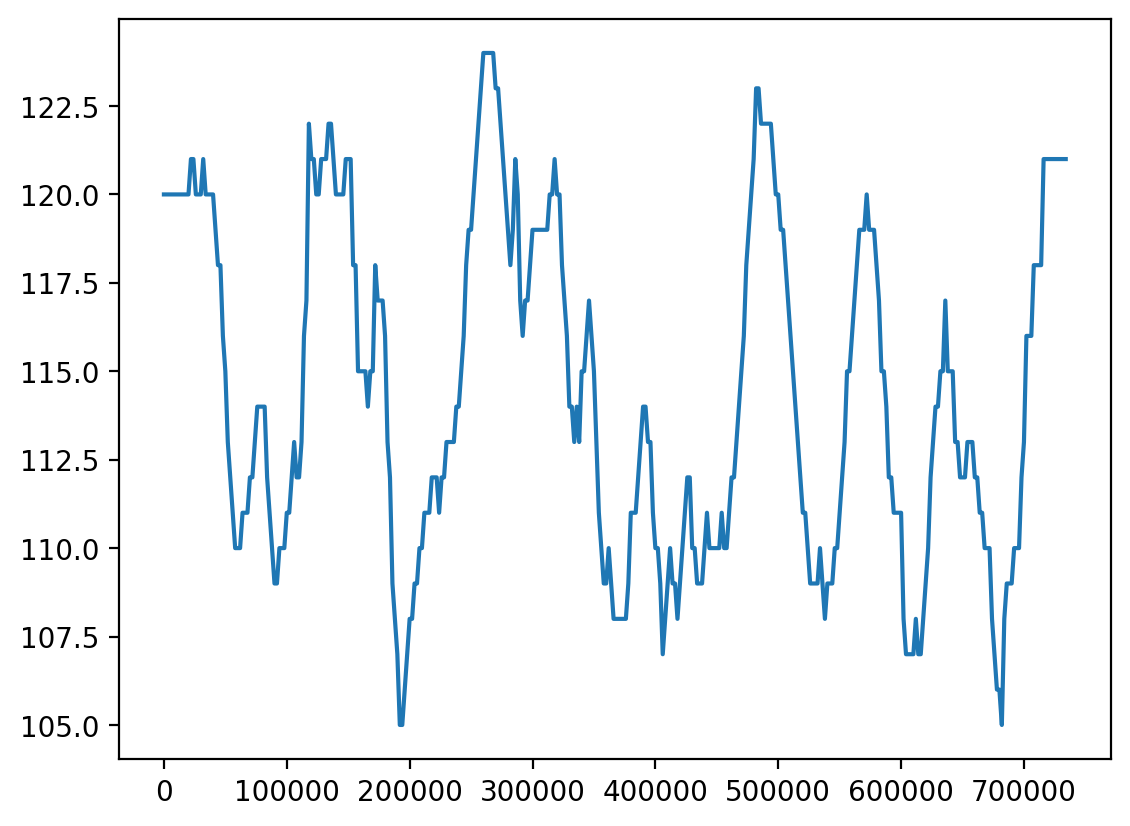

In [334]:
plt.plot(repl_timing.loc[10])